# fastDSA tutorial
In this notebook we demonstrate a minimal end-to-end workflow for comparing two collections of time series using fastDSA.

## Imports and API entrypoints
- `SimDistConfig`: configuration object that controls delay embedding, rank selection, optimization hyperparameters, and the similarity method.
  
- `FastDSASimilarity`: high-level pipeline that computes DMD operators (with delay embedding and optional SVHT rank selection) and evaluates a similarity score.

In [9]:
from fastDSA.simdist import SimDistConfig, FastDSASimilarity
import numpy as np
from scipy.integrate import solve_ivp
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

## Load data or generate synthetic trajectories

This cell prepares two datasets of trajectories:

- Dataset A and Dataset B can be loaded from disk (each trial stored as a .npy file), or

- generated synthetically from two nonlinear 2D dynamical systems using solve_ivp.

The loader assumes each .npy file is shaped (T, n_features) where T is the number of time points. The synthetic option produces a small set of trajectories for each system with randomized initial conditions, which is useful for validating the pipeline without external data.

At the end of the cell we print how many trajectories were loaded/generated and the shape of an example trial.

In [10]:
use_synthetic = True  # <-- set to False to load from folders

folder_A = ""   # folder of .npy files for Dataset A (if not synthetic)
folder_B = ""   # folder of .npy files for Dataset B (if not synthetic)

def load_trajs_from_folder(folder: str):
    """Load all .npy files in a folder as a list of arrays (T, n_features).\"\"\"\"\"\""""
    path = Path(folder)
    if not path.exists():
        raise FileNotFoundError(f"Folder not found: {folder}")
    trajs = []
    for f in sorted(path.glob("*.npy")):
        arr = np.load(f, allow_pickle=False)
        if arr.ndim != 2:
            raise ValueError(f'File {f} must be 2D (T, n_features). Got shape {arr.shape}.' )
        trajs.append(arr)
    if len(trajs) == 0:
        raise ValueError(f'No .npy files found in {folder}')
    return trajs

# --- Synthetic demo systems (2D) ---
def system_a(t, state, eps=0.5):
    x, y = state
    dx = -1.0 * x + eps * x * y
    dy = -2.0 * y - eps * x**2
    return [dx, dy]

def system_b(t, state, eps=0.5):
    x, y = state
    dx = -1.5 * x + 0.5 * y - eps * x**2
    dy = 0.5 * x - 1.5 * y - eps * y**2
    # dx = -1.0 * x + eps * x * y
    # dy = -3.0 * y - eps * x**2
    return [dx, dy]

def generate_trajectory(system, x0, T=10.0, dt=0.01, eps=0.5):
    t_eval = np.arange(0, T, dt)
    sol = solve_ivp(system, (0, T), x0, t_eval=t_eval, args=(eps,))
    return sol.y.T  # (T, 2)

if use_synthetic:
    # Build small demo sets
    num_per_set = 10
    T=10.0; dt=0.01
    eps=0.6
    rng = np.random.default_rng(44)

    dataset_A = [generate_trajectory(system_a, rng.uniform(-4,4,size=2), T=T, dt=dt, eps=eps) for _ in range(num_per_set)]
    dataset_B = [generate_trajectory(system_b, rng.uniform(-4,4,size=2), T=T, dt=dt, eps=eps) for _ in range(num_per_set)]
else:
    dataset_A = load_trajs_from_folder(folder_A)
    dataset_B = load_trajs_from_folder(folder_B)

print(f"Loaded {len(dataset_A)} trajectories for A, {len(dataset_B)} for B.")
print(f'Example shape A[0]: {dataset_A[0].shape}.')

Loaded 10 trajectories for A, 10 for B.
Example shape A[0]: (1000, 2).


### What are the synthetic networks?

The synthetic option creates two small collections of trajectories from two different 2D nonlinear dynamical systems. In this tutorial, `system_a` and `system_b` act as stand-ins for two different networks: each one defines how the current state `(x, y)` changes over time through its derivatives `(dx/dt, dy/dt)`.

The two systems used here are:

$$
\begin{aligned}
\text{System A:}\quad
\frac{dx}{dt} &= -x + \epsilon xy, \\
\frac{dy}{dt} &= -2y - \epsilon x^2,
\end{aligned}
$$

$$
\begin{aligned}
\text{System B:}\quad
\frac{dx}{dt} &= -1.5x + 0.5y - \epsilon x^2, \\
\frac{dy}{dt} &= 0.5x - 1.5y - \epsilon y^2.
\end{aligned}
$$

In the synthetic demo below, `epsilon` is set to `0.5`.

Each dataset contains multiple trials from the same underlying system, but with randomized initial conditions. This gives us controlled data where trials within a dataset share the same generating dynamics, while Dataset A and Dataset B come from different dynamics. The later fastDSA distance matrix should therefore help reveal whether trajectories generated by the same system are more similar to each other than to trajectories from the other system.

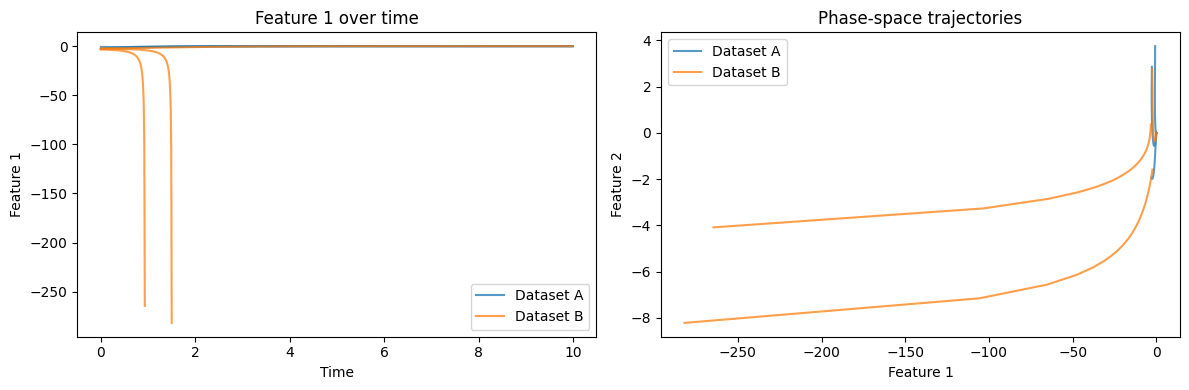

In [11]:
# Quick visual check of the generated or loaded trajectories.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

time_scale = dt if use_synthetic and "dt" in globals() else 1.0
datasets_to_plot = [("Dataset A", dataset_A, "tab:blue"), ("Dataset B", dataset_B, "tab:orange")]

for label, dataset, color in datasets_to_plot:
    for trial_idx, traj in enumerate(dataset[:3]):
        t = np.arange(traj.shape[0]) * time_scale
        axes[0].plot(t, traj[:, 0], color=color, alpha=0.75, label=label if trial_idx == 0 else None)

        if traj.shape[1] >= 2:
            axes[1].plot(traj[:, 0], traj[:, 1], color=color, alpha=0.75, label=label if trial_idx == 0 else None)

axes[0].set_title("Feature 1 over time")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Feature 1")
axes[0].legend()

if min(traj.shape[1] for _, dataset, _ in datasets_to_plot for traj in dataset) >= 2:
    axes[1].set_title("Phase-space trajectories")
    axes[1].set_xlabel("Feature 1")
    axes[1].set_ylabel("Feature 2")
    axes[1].legend()
else:
    axes[1].axis("off")

plt.tight_layout()
plt.show()

## Compute fastDSA pairwise distances across trials

fastDSA expects each trial in the shape `(channels, timepoints)`, while our synthetic generator (and typical `.npy` storage) uses `(timepoints, features)`. We therefore transpose each trajectory to match the package convention.

We then configure and run fastDSA in two stages:

1. Global rank selection (SVHT):
We call `fit_score` once on the full datasets with `rank=None`. This triggers automatic rank detection via SVHT and returns a single `used_rank` that is consistent across both datasets. Using a fixed rank improves stability and comparability for pairwise distances.

2. Pairwise distance matrix:
With `rank=used_rank`, we compute fastDSA distances for every pair of trials across the combined set `A ∪ B`, producing a symmetric distance matrix `dist_mat` of shape `(N, N)`.

You can switch `method` to compare different similarity backends supported by the package (e.g., `"ro"`, `"rim"`, `"land"`).

In [ ]:
import sys
import numpy as np
import torch
import pandas as pd

from fastDSA.simdist import SimDistConfig, FastDSASimilarity

# Optional but useful: confirm VS Code is using the correct environment
print("Python executable:", sys.executable)


def to_channels_time(traj_Tn: np.ndarray) -> np.ndarray:
    """
    Convert one trajectory from (timepoints, features) to (channels, timepoints).

    Input:
        traj_Tn: shape (T, n_features)

    Output:
        shape (n_features, T)
    """
    traj_Tn = np.asarray(traj_Tn)

    if traj_Tn.ndim != 2:
        raise ValueError(
            f"Trajectory must be 2D with shape (T, n_features). Got {traj_Tn.shape}"
        )

    return traj_Tn.T.astype(np.float32)


# ------------------------------------------------------------
# 1) Convert datasets to the format expected by fastDSA
# ------------------------------------------------------------

dataset_A_ct = [to_channels_time(tr) for tr in dataset_A]
dataset_B_ct = [to_channels_time(tr) for tr in dataset_B]

all_trials = dataset_A_ct + dataset_B_ct
N = len(all_trials)

print(f"Number of A trials: {len(dataset_A_ct)}")
print(f"Number of B trials: {len(dataset_B_ct)}")
print(f"Total trials: {N}")
print(f"Example trial shape: {all_trials[0].shape}  # (channels, timepoints)")


# ------------------------------------------------------------
# 2) Define fastDSA settings
# ------------------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"

# New default:
# n_delays=None means: use automatic q_star-SVHT selector.
# delay_interval=1 means consecutive-delay Hankel/eigendelay construction.
n_delays = None
delay_interval = None


method = "land"          # options: "ro", "rim", "land", "kw"
iters = 200
lr = 1e-2



# ------------------------------------------------------------
# 3) Run q_star-SVHT once globally
# ------------------------------------------------------------
# This performs:
#   q0 from ACF / dominant period / N^(1/3)
#   pilot Hankel
#   SVHT rank r0
#   rank-pressure p0 = r0 / q0
#   q_star = min(ceil(q0 * (1 + p0^2)), floor((N + 1) / 2))
#   final SVHT rank
#
# We do this once using all A and B trials, then reuse the same q_star and rank
# for all pairwise distances.

cfg_select = SimDistConfig(
    n_delays=n_delays,          # None -> automatic q_star
    delay_interval=delay_interval,
    rank=None,                  # None -> automatic SVHT rank
    method=method,
    iters=1,                   # cheap selection/probe run
    lr=lr,
    device=device,
    verbose=True,
)

sim_select = FastDSASimilarity(cfg_select)

_, used_rank = sim_select.fit_score(dataset_A_ct, dataset_B_ct)

# Extract selected q_star / n_delays from the updated class.
# These attributes exist in the updated simdist.py.
selected_n_delays = getattr(sim_select, "selected_n_delays_", None)
selected_delay_interval = getattr(sim_select, "selected_delay_interval_", delay_interval)

if selected_n_delays is None:
    # fallback for older class versions
    selected_n_delays = getattr(sim_select.config, "n_delays", None)

if selected_n_delays is None:
    raise RuntimeError(
        "Could not find selected_n_delays_. "
        "Make sure you copied the updated simdist.py and q_star.py into src/fastDSA/."
    )

selected_n_delays = int(selected_n_delays)
selected_delay_interval = int(selected_delay_interval)
used_rank = int(used_rank)

print("\nSelected global embedding parameters")
print("------------------------------------")
print("q_star / n_delays:", selected_n_delays)
print("delay_interval:", selected_delay_interval)
print("SVHT rank:", used_rank)

# Optional diagnostics from q_star
if hasattr(sim_select, "q_star_result_") and sim_select.q_star_result_ is not None:
    print("\nq_star result:")
    display(pd.DataFrame([sim_select.q_star_result_]))

if hasattr(sim_select, "hankel_selection_table_") and sim_select.hankel_selection_table_ is not None:
    print("\nHankel selection table:")
    display(pd.DataFrame(sim_select.hankel_selection_table_))


# ------------------------------------------------------------
# 4) Compute pairwise distance matrix using fixed q_star and rank
# ------------------------------------------------------------
# Important:
# We now use fixed selected_n_delays and used_rank.
# This avoids re-running q_star separately for every pair.
# It also makes all pairwise distances comparable.

cfg_pairwise = SimDistConfig(
    n_delays=selected_n_delays,
    delay_interval=selected_delay_interval,
    rank=used_rank,
    method=method,
    iters=iters,
    lr=lr,
    eta=None,
    device=device,
    verbose=False,
)

dist_mat = np.zeros((N, N), dtype=float)

for i in range(N):
    for j in range(i + 1, N):

        sim = FastDSASimilarity(cfg_pairwise)

        # Use singleton lists: [trial_i], [trial_j]
        # This avoids treating a (C, T) array as a list of channels.
        d, _ = sim.fit_score([all_trials[i]], [all_trials[j]])

        dist_mat[i, j] = dist_mat[j, i] = float(d)

print("\nDistance matrix shape:", dist_mat.shape)
print(dist_mat)

Python executable: /Users/behradarm/Documents/git/.fastDSA/bin/python
Number of A trials: 10
Number of B trials: 10
Total trials: 20
Example trial shape: (2, 1000)  # (channels, timepoints)
[q_star] q0 estimate: {'N': 1000, 'q_acf': 238, 'q_period': 0, 'q_prop': 20, 'q0': 238, 'q_geom': 500}
[q_star] q0=238, r0=110, p0=0.462, q_star=289, r_star=130
[q_star] q0 estimate: {'N': 1000, 'q_acf': 173, 'q_period': 0, 'q_prop': 20, 'q0': 173, 'q_geom': 500}
[q_star] q0=173, r0=70, p0=0.405, q_star=202, r_star=81
[q_star] q0 estimate: {'N': 1000, 'q_acf': 269, 'q_period': 0, 'q_prop': 20, 'q0': 269, 'q_geom': 500}
[q_star] q0=269, r0=118, p0=0.439, q_star=321, r_star=133
[q_star] q0 estimate: {'N': 1000, 'q_acf': 259, 'q_period': 0, 'q_prop': 20, 'q0': 259, 'q_geom': 500}
[q_star] q0=259, r0=113, p0=0.436, q_star=309, r_star=132
[q_star] q0 estimate: {'N': 1000, 'q_acf': 168, 'q_period': 0, 'q_prop': 20, 'q0': 168, 'q_geom': 500}
[q_star] q0=168, r0=82, p0=0.488, q_star=209, r_star=95
[q_star] 

100%|██████████| 1/1 [00:00<00:00, 212.54it/s]


Selected global embedding parameters
------------------------------------
q_star / n_delays: 33
delay_interval: 1
SVHT rank: 16

q_star result:


,n_delays,delay_interval,rank,q_global,rank_global,q_feasible_global,q_candidate_before_feasibility_clip,q_global_was_clipped,selected_rows,diagnostic_rows
0,"[[33, 33, 33, 33, 33, 33, 33, 33, 33, 33], [33...","[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1], [1, 1, 1, 1, ...","[[16, 16, 16, 16, 16, 16, 16, 16, 16, 16], [16...",33,16,47,33,False,"[{'N': 1000, 'q_min': 32, 'q_geom': 500, 'q_ac...","[{'stage': 'pilot_q0', 'q0': 238, 'r0_svht': 1..."



Hankel selection table:


,N,q_min,q_geom,q_acf,q_period,q_prop,q_pre,q0,tau_int_samples,first_nonpositive_lag,...,r_star,SVHT_threshold,energy_retained,final_embedded_rows,final_embedded_cols,final_n_singular_values,final_n_above_SVHT,selection_rule,data_block,data_index
0,1000,32,500,238,0,20,238,238,118.665799,230,...,130,4.715292e-07,1.0,289,712,289,130,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,0
1,1000,32,500,173,0,20,173,173,86.440683,173,...,81,3.875978e-06,1.0,202,799,202,81,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,1
2,1000,32,500,269,0,20,269,269,134.472923,232,...,133,1.124044e-06,1.0,321,680,321,133,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,2
3,1000,32,500,259,0,20,259,259,129.160198,234,...,132,4.149939e-07,1.0,309,692,309,132,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,3
4,1000,32,500,168,0,20,168,168,83.961622,244,...,95,1.352252e-06,1.0,209,792,209,95,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,4
5,1000,32,500,58,0,20,58,58,28.956102,40,...,29,9.928028e-05,1.0,69,932,69,29,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,5
6,1000,32,500,81,0,20,81,81,40.361343,54,...,43,9.000216e-05,1.0,97,904,97,43,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,6
7,1000,32,500,65,0,20,65,65,32.286714,55,...,34,2.311037e-04,1.0,78,923,78,34,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,7
8,1000,32,500,144,0,20,144,144,71.506103,223,...,69,3.225405e-05,1.0,170,831,170,69,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,8
9,1000,32,500,372,0,20,372,372,185.590997,244,...,179,1.092290e-06,1.0,438,563,438,179,"q_star = min(ceil(q0 * (1 + (r0/q0)^2)), floor...",0,9



Distance matrix shape: (20, 20)
[[0.         0.70824099 0.18171291 0.28008619 0.5282554  0.19326629
  0.12416035 0.48680773 0.35970804 0.43308684 0.53609884 1.33893728
  1.33654416 0.59049499 0.62446839 1.33994091 0.51182604 1.32539999
  0.61592728 1.35488546]
 [0.70824099 0.         0.71488941 0.71852922 0.74383295 0.72762096
  0.71716446 0.6533969  0.6779961  0.38519827 0.66225487 0.7851398
  0.         0.76295215 0.71131939 0.78560668 0.71012956 0.77450502
  0.76218241 0.        ]
 [0.18171291 0.71488941 0.         0.09612425 0.35822654 0.34983602
  0.21617915 0.5844577  0.21232817 0.47372118 0.46364003 1.28197265
  1.27852333 0.50207603 0.59113032 1.28314531 0.39438707 1.26936305
  0.53102213 1.29969156]
 [0.28008619 0.71852922 0.09612425 0.         0.36898568 0.19660525
  0.32014051 0.5270431  0.31963935 0.49660483 0.4384332  1.31509769
  1.31206667 0.46919334 0.56326723 1.31479013 0.34576568 1.29980862
  0.50383639 1.33229363]
 [0.5282554  0.74383295 0.35822654 0.36898568 0.    

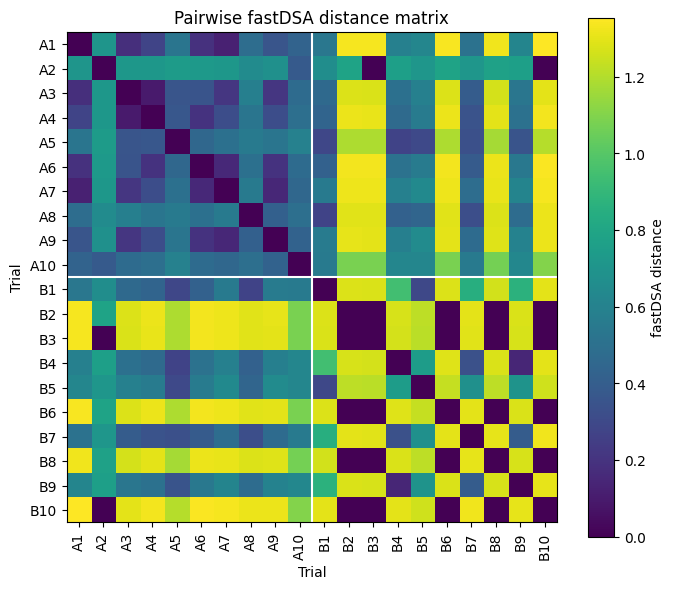

In [16]:
# Simple color plot of the pairwise fastDSA distance matrix.
plt.figure(figsize=(7, 6))
im = plt.imshow(dist_mat, cmap="viridis", interpolation="nearest")
plt.colorbar(im, label="fastDSA distance")

nA_dist = len(dataset_A_ct)
plt.axhline(nA_dist - 0.5, color="white", linewidth=1.5)
plt.axvline(nA_dist - 0.5, color="white", linewidth=1.5)

trial_labels = [f"A{i + 1}" for i in range(len(dataset_A_ct))] + [f"B{i + 1}" for i in range(len(dataset_B_ct))]
plt.xticks(np.arange(N), trial_labels, rotation=90)
plt.yticks(np.arange(N), trial_labels)
plt.xlabel("Trial")
plt.ylabel("Trial")
plt.title("Pairwise fastDSA distance matrix")
plt.tight_layout()
plt.show()

## Embed trials with MDS and visualize separation

Given the pairwise fastDSA distance matrix, we compute a 2D embedding using Multidimensional Scaling (MDS) with `dissimilarity="precomputed"`. This produces 2D coordinates for each trial such that Euclidean distances in the embedding reflect fastDSA dissimilarities as closely as possible.

Finally, we plot the embedded points and color them by dataset membership (A vs B). The figure is saved to both PDF and SVG for inclusion in reports, papers, or documentation, and also displayed inline in the notebook.

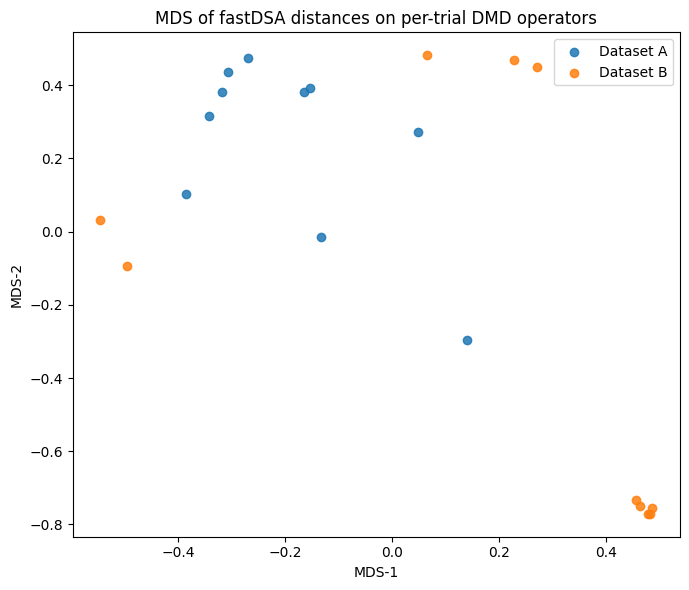

In [17]:
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(dist_mat)

nA = len(dataset_A_ct)
labels = np.array([0] * nA + [1] * (len(dataset_B_ct)))

plt.figure(figsize=(7, 6))
plt.scatter(coords[labels == 0, 0], coords[labels == 0, 1], label="Dataset A", alpha=0.85)
plt.scatter(coords[labels == 1, 0], coords[labels == 1, 1], label="Dataset B", alpha=0.85)
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.title("MDS of fastDSA distances on per-trial DMD operators")
plt.legend()
plt.tight_layout()

plt.savefig(".pdf", bbox_inches="tight")
plt.savefig(".svg", bbox_inches="tight")
plt.show()